<a href="https://colab.research.google.com/github/vishalmmca25-design/ml-and-datavisualization/blob/main/lab2_seaborn_basics_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## 1. Setup and datasets

We use two datasets:

* **tips** — 244 restaurant bills, with the bill amount, the tip and details such
  as the day and the time of the meal. Seaborn downloads it with
  `sns.load_dataset("tips")`.
* **iris** — 150 flowers, loaded from `scikit-learn` so it always works.

If the computer has no internet connection, the cell below builds a small
substitute for `tips` with the same columns, so the rest of the notebook still runs.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas  :", pd.__version__)
print("Seaborn :", sns.__version__)

%matplotlib inline

# sns.set_theme() applies Seaborn's nicer default look
sns.set_theme(style="whitegrid")
print("\nSetup complete.")

pandas  : 2.2.2
Seaborn : 0.13.2

Setup complete.


In [ ]:
# Load the tips dataset (with an offline substitute if there is no internet)
try:
    tips = sns.load_dataset("tips")
    print("tips downloaded from seaborn.")
except Exception:
    rng = np.random.default_rng(0)
    n = 244
    bill = np.round(np.exp(rng.normal(2.85, 0.42, n)).clip(3, 51), 2)
    tips = pd.DataFrame({
        "total_bill": bill,
        "tip": np.round((bill * rng.normal(0.16, 0.04, n)).clip(1, 10), 2),
        "sex": rng.choice(["Male", "Female"], n),
        "smoker": rng.choice(["No", "Yes"], n),
        "day": rng.choice(["Thur", "Fri", "Sat", "Sun"], n),
        "time": rng.choice(["Lunch", "Dinner"], n),
        "size": rng.choice([2, 3, 4], n),
    })
    print("No internet: using an offline substitute for tips.")

print("Shape:", tips.shape)
print("\nFirst 5 rows:")
print(tips.head())

tips downloaded from seaborn.
Shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
# Load the Iris dataset from scikit-learn (never needs internet)
from sklearn.datasets import load_iris

data = load_iris()
iris = pd.DataFrame(data.data, columns=["sepal_length", "sepal_width",
                                        "petal_length", "petal_width"])
iris["species"] = data.target_names[data.target]

print("Shape:", iris.shape)
print(iris.head())

Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


---
## 2. Seaborn vs Matplotlib

Seaborn is **built on top of Matplotlib**. It does not replace it — it gives
shorter commands for common charts. Two main advantages:

1. You pass the whole DataFrame with `data=` and name the columns with `x=` and `y=`.
2. `hue="column"` splits the data by a category, gives each group a colour and
   builds the legend **automatically**.

In Lab 1 we needed a `for` loop and a colour dictionary to do this. Compare below.

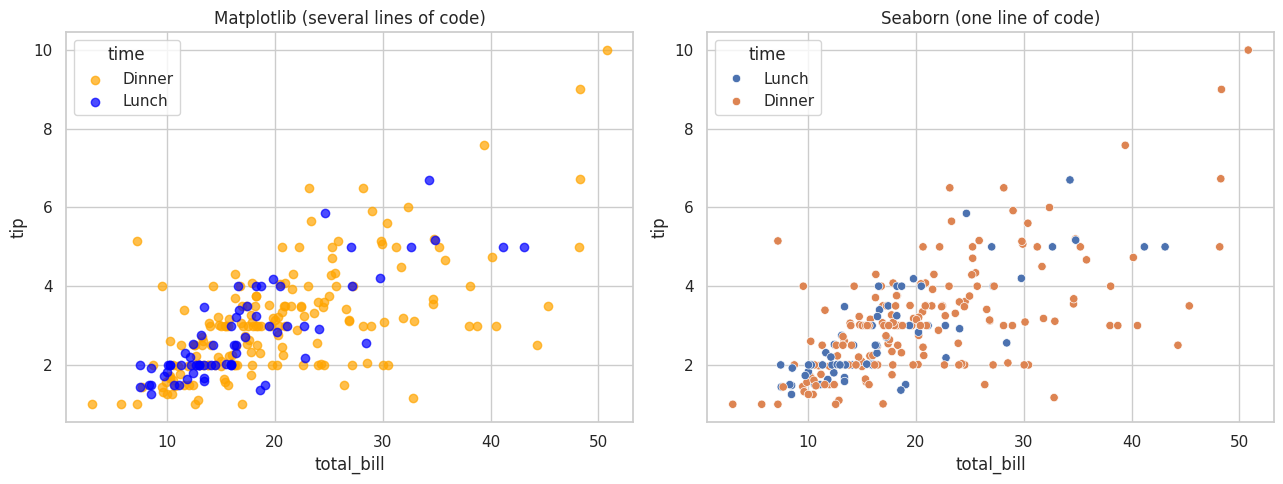

Both give the same result. Seaborn made the groups, colours and legend itself.


In [ ]:
# The same chart written both ways
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Matplotlib: a loop, a colour for each group, and a legend ----
colors = {"Lunch": "blue", "Dinner": "orange"}
for name in tips["time"].unique():
    group = tips[tips["time"] == name]
    axes[0].scatter(group["total_bill"], group["tip"],
                    color=colors[name], alpha=0.7, label=name)
axes[0].set_xlabel("total_bill")
axes[0].set_ylabel("tip")
axes[0].legend(title="time")
axes[0].set_title("Matplotlib (several lines of code)")

# ---- Seaborn: one line ----
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=axes[1])
axes[1].set_title("Seaborn (one line of code)")

plt.tight_layout()
plt.show()

print("Both give the same result. Seaborn made the groups, colours and legend itself.")

---
## 3. Scatter plot and `hue`

`sns.scatterplot(data=df, x="col1", y="col2")` draws a scatter plot.

Three extra arguments split the data by a category:

| Argument | Effect |
|---|---|
| `hue="col"` | a different **colour** for each group |
| `style="col"` | a different **marker shape** for each group |
| `size="col"` | a different **point size** for each group |

Use one or two of them. Using all three at once makes the plot hard to read.

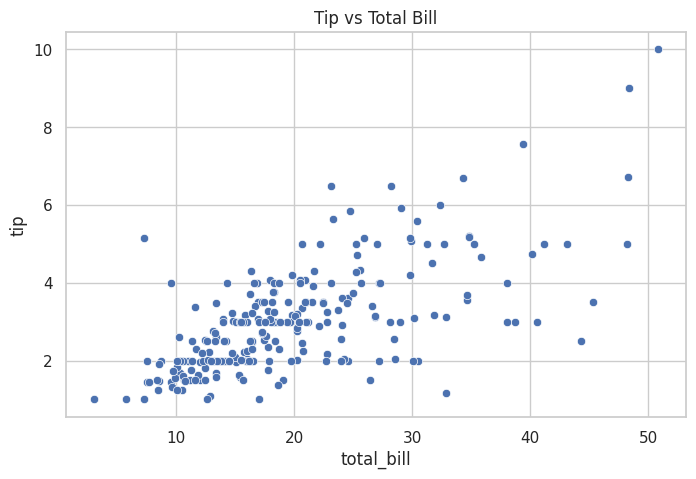

In [ ]:
# Plain scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax)
ax.set_title("Tip vs Total Bill")
plt.show()

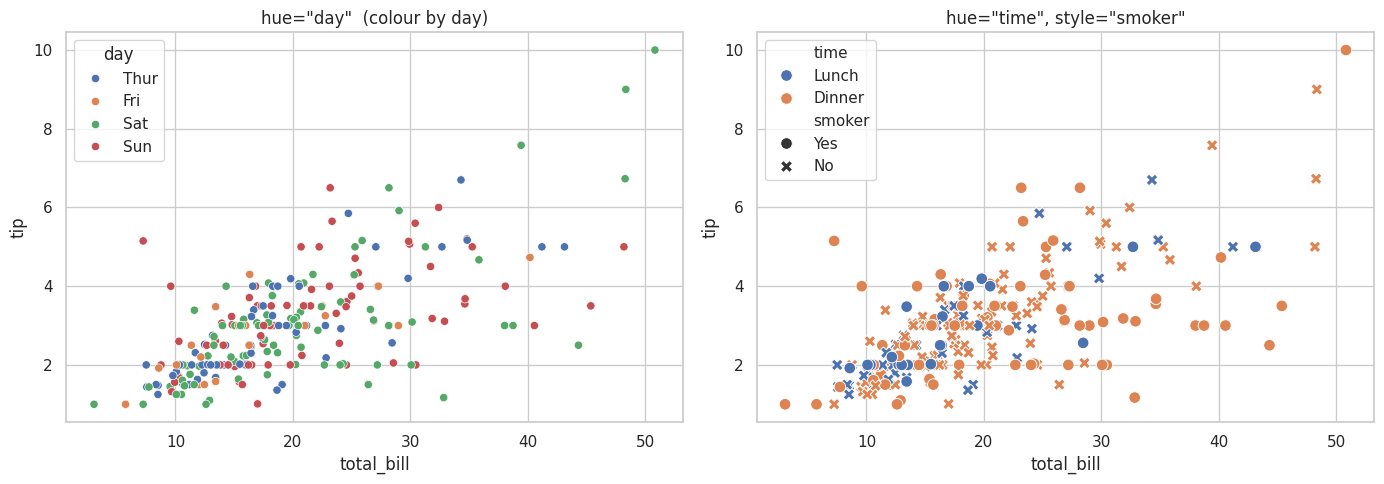

The legend is created automatically in both cases.


In [ ]:
# Adding hue and style
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", ax=axes[0])
axes[0].set_title('hue="day"  (colour by day)')

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time",
                style="smoker", s=70, ax=axes[1])
axes[1].set_title('hue="time", style="smoker"')

plt.tight_layout()
plt.show()

print("The legend is created automatically in both cases.")

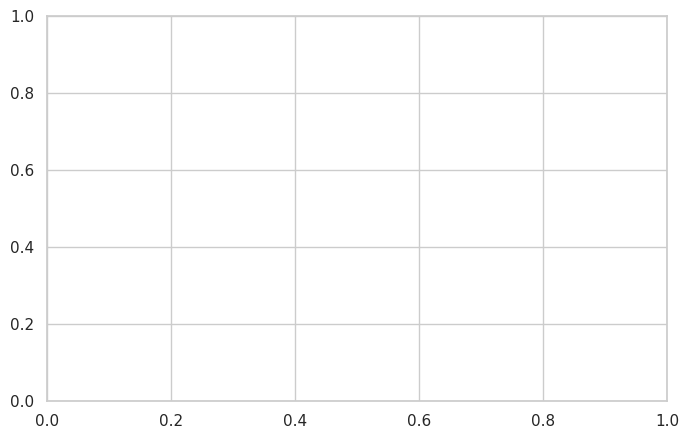

In [ ]:
# TRY IT
# Draw a scatter plot of the iris data:
#   x = "petal_length",  y = "petal_width",  hue = "species"
# Add a title.

fig, ax = plt.subplots(figsize=(8, 5))

# --- write your code below ---


plt.show()

---
## 4. Line plot

`sns.lineplot(data=df, x=..., y=...)` joins the points in order of x.
It is mainly used for data that changes over time.

  month  sales  cost
0   Jan    120   100
1   Feb    135   110
2   Mar    150   118
3   Apr    145   120
4   May    170   130
5   Jun    190   140


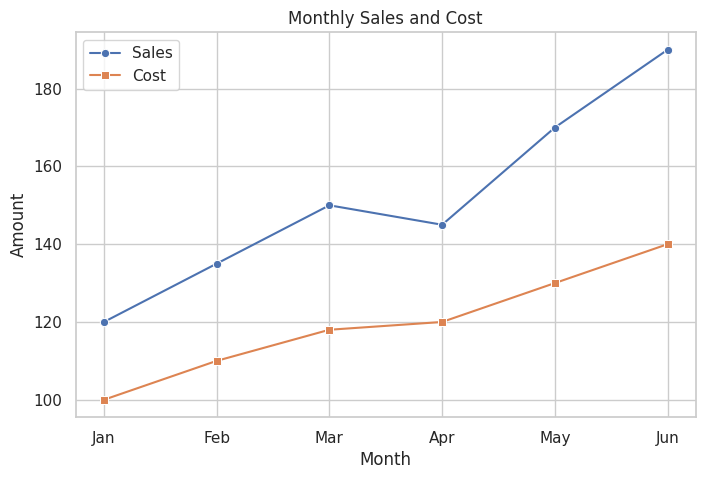

In [ ]:
# A small table of monthly sales
sales = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "sales": [120, 135, 150, 145, 170, 190],
    "cost":  [100, 110, 118, 120, 130, 140],
})
print(sales)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=sales, x="month", y="sales", marker="o", label="Sales", ax=ax)
sns.lineplot(data=sales, x="month", y="cost", marker="s", label="Cost", ax=ax)

ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.set_title("Monthly Sales and Cost")
plt.show()

---
## 5. Histogram and KDE

| Function | What it draws |
|---|---|
| `sns.histplot(data=df, x="col")` | a histogram (bars of counts) |
| `sns.histplot(..., kde=True)` | a histogram with a smooth curve on top |
| `sns.kdeplot(data=df, x="col")` | only the smooth curve |

The smooth curve is called a **KDE** (kernel density estimate). It shows the
shape of the data without using bars.

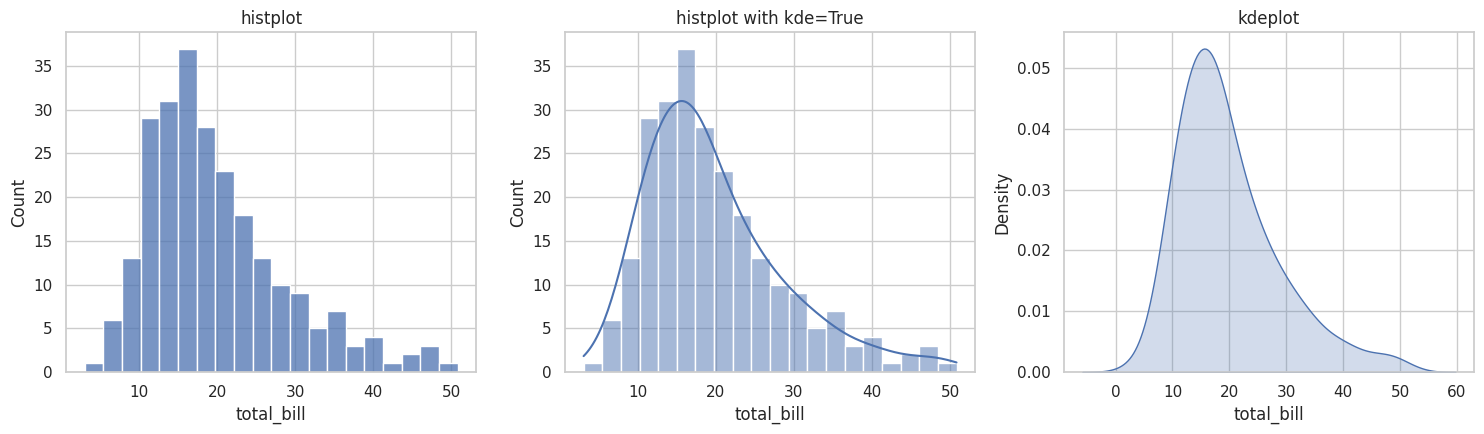

In [ ]:
# Three views of one column
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(data=tips, x="total_bill", bins=20, ax=axes[0])
axes[0].set_title("histplot")

sns.histplot(data=tips, x="total_bill", bins=20, kde=True, ax=axes[1])
axes[1].set_title("histplot with kde=True")

sns.kdeplot(data=tips, x="total_bill", fill=True, ax=axes[2])
axes[2].set_title("kdeplot")

plt.tight_layout()
plt.show()

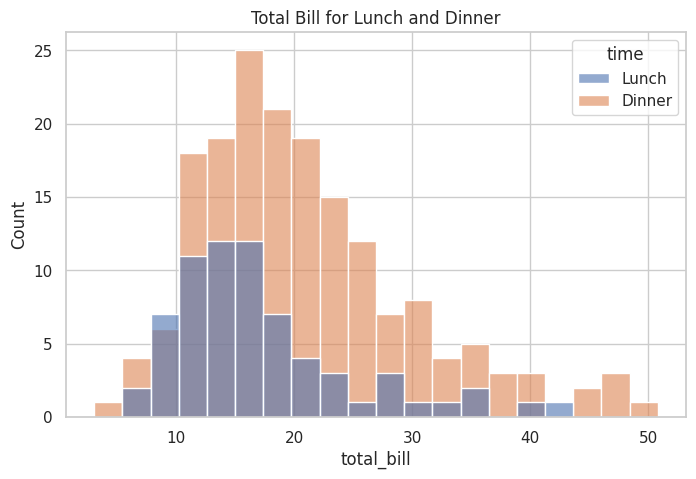

time
Dinner    176
Lunch      68
Name: count, dtype: int64


In [ ]:
# Comparing two groups with hue
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=tips, x="total_bill", hue="time", bins=20, alpha=0.6, ax=ax)
ax.set_title("Total Bill for Lunch and Dinner")
plt.show()

print(tips["time"].value_counts())

---
## 6. Bar plot and count plot

These two look similar but answer **different** questions:

| Function | Height of the bar |
|---|---|
| `sns.countplot(data=df, x="col")` | **how many rows** are in each category |
| `sns.barplot(data=df, x="cat", y="num")` | the **average** of the numeric column |

The thin vertical line on a `barplot` bar shows the uncertainty of the average.

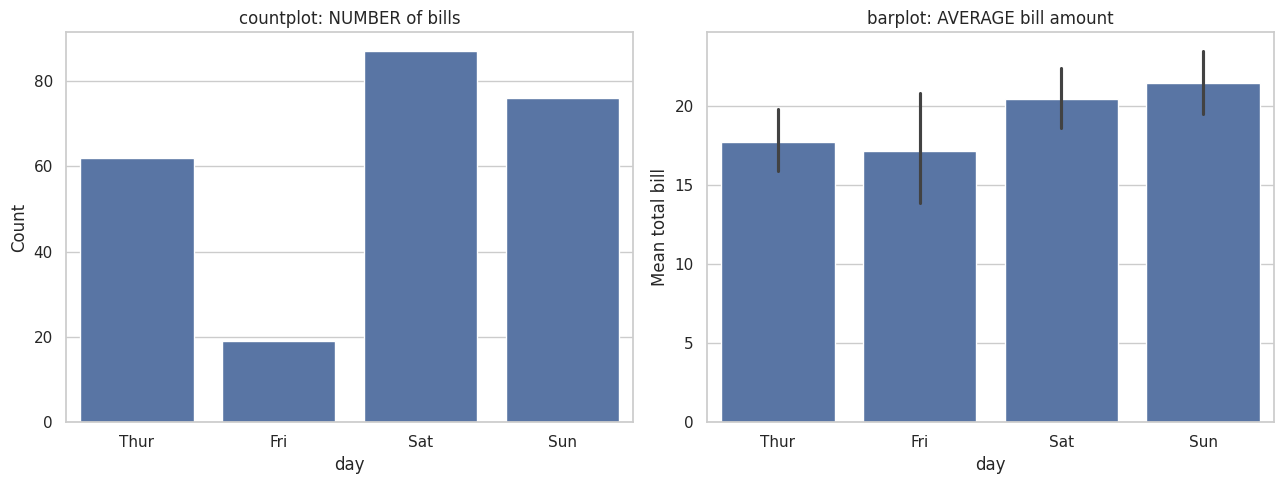

      count   mean
day               
Thur     62  17.68
Fri      19  17.15
Sat      87  20.44
Sun      76  21.41

Saturday has the most bills, but Sunday has the highest average bill.


In [ ]:
# countplot = number of bills, barplot = average bill
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=tips, x="day", ax=axes[0])
axes[0].set_title("countplot: NUMBER of bills")
axes[0].set_ylabel("Count")

sns.barplot(data=tips, x="day", y="total_bill", ax=axes[1])
axes[1].set_title("barplot: AVERAGE bill amount")
axes[1].set_ylabel("Mean total bill")

plt.tight_layout()
plt.show()

print(tips.groupby("day", observed=True)["total_bill"].agg(["count", "mean"]).round(2))
print("\nSaturday has the most bills, but Sunday has the highest average bill.")

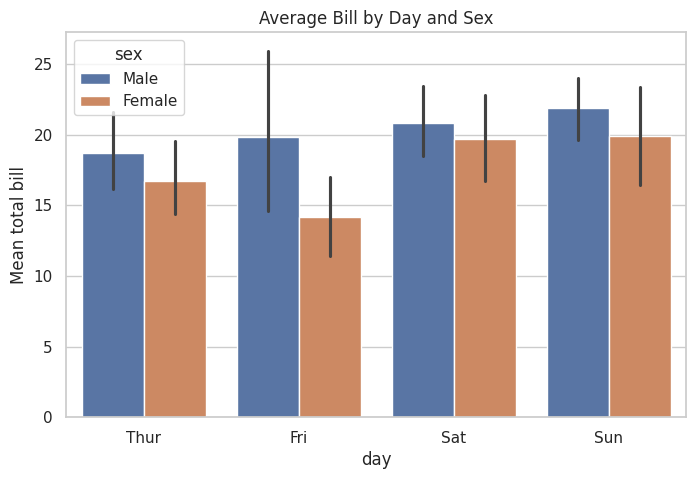

In [ ]:
# Splitting the bars by a second category with hue
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", ax=ax)
ax.set_title("Average Bill by Day and Sex")
ax.set_ylabel("Mean total bill")
plt.show()

---
## 7. Box plot and violin plot

* `sns.boxplot()` — the five-number summary (minimum, Q1, median, Q3, maximum).
* `sns.violinplot()` — the same idea, but the width shows how many values are at
  each height, so the **shape** of the data is visible.

Notice how much shorter this is than the Matplotlib box plot in Lab 1: Seaborn
does the grouping for you.

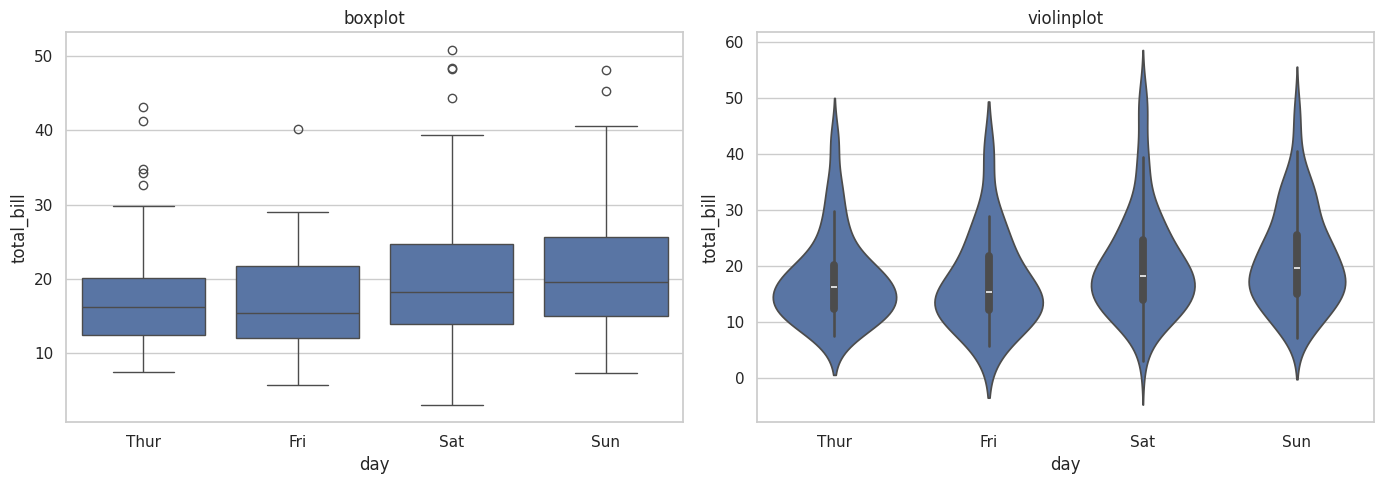

In [ ]:
# Box plot and violin plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[0])
axes[0].set_title("boxplot")

sns.violinplot(data=tips, x="day", y="total_bill", ax=axes[1])
axes[1].set_title("violinplot")

plt.tight_layout()
plt.show()

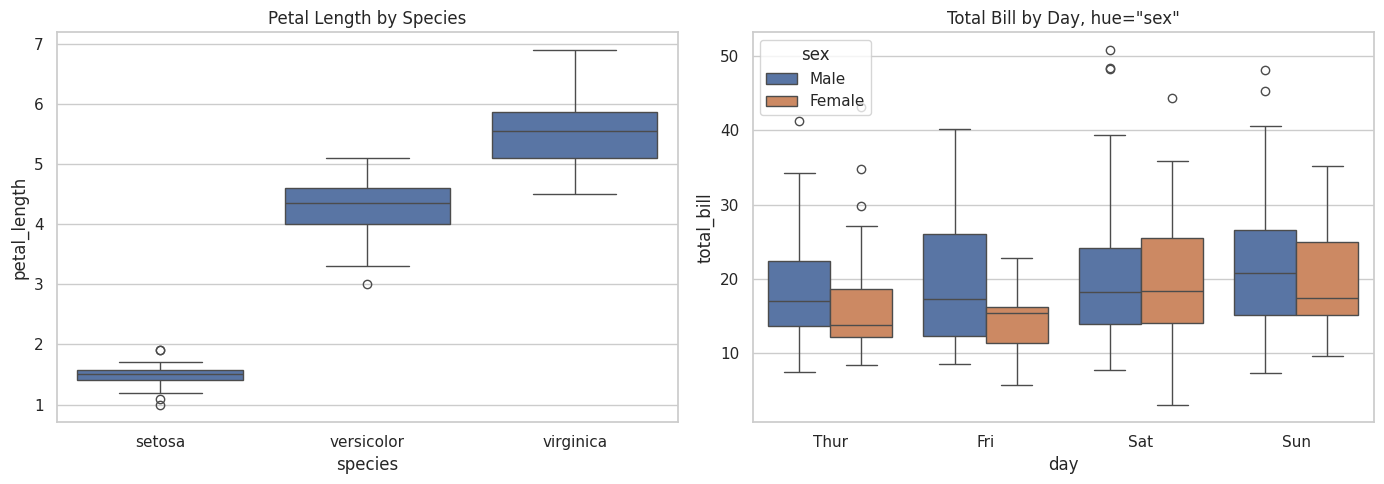

species
setosa        1.50
versicolor    4.35
virginica     5.55
Name: petal_length, dtype: float64


In [ ]:
# The same plots on the iris data, with hue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=iris, x="species", y="petal_length", ax=axes[0])
axes[0].set_title("Petal Length by Species")

sns.boxplot(data=tips, x="day", y="total_bill", hue="sex", ax=axes[1])
axes[1].set_title('Total Bill by Day, hue="sex"')

plt.tight_layout()
plt.show()

print(iris.groupby("species")["petal_length"].median())

---
## 8. Heatmap

`sns.heatmap(matrix)` shows a table of numbers as colours. Its most common use is
a **correlation matrix**, which measures how strongly each pair of numeric
columns move together:

* close to **+1** → they increase together
* close to **0** → no relationship
* close to **-1** → one increases while the other decreases

Useful arguments: `annot=True` writes the numbers in the boxes, and
`cmap="coolwarm"` chooses the colours.

              sepal_length  sepal_width  petal_length  petal_width
sepal_length          1.00        -0.12          0.87         0.82
sepal_width          -0.12         1.00         -0.43        -0.37
petal_length          0.87        -0.43          1.00         0.96
petal_width           0.82        -0.37          0.96         1.00


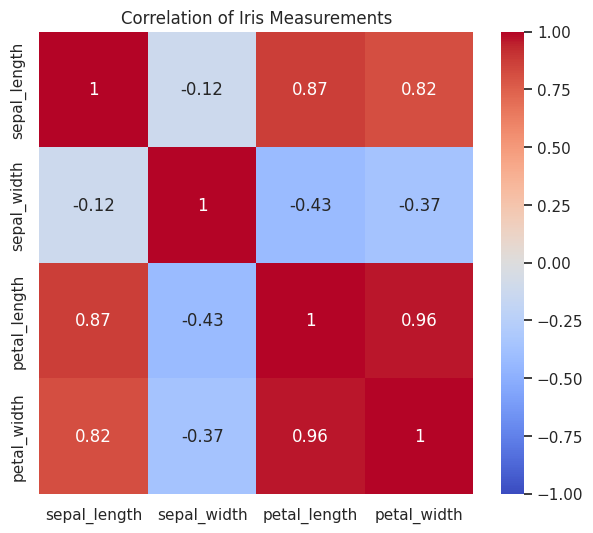


Petal length and petal width have the strongest relationship (about 0.96).


In [ ]:
# Correlation between the four iris measurements
numbers = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
corr = numbers.corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation of Iris Measurements")
plt.show()

print("\nPetal length and petal width have the strongest relationship (about 0.96).")

---
## 9. Pair plot

`sns.pairplot(df, hue="category")` draws a grid with a scatter plot for **every
pair** of numeric columns, and the distribution of each column on the diagonal.

It is the quickest way to look at a whole dataset at once. Note that it draws the
complete figure itself, so it does **not** take an `ax=` argument.

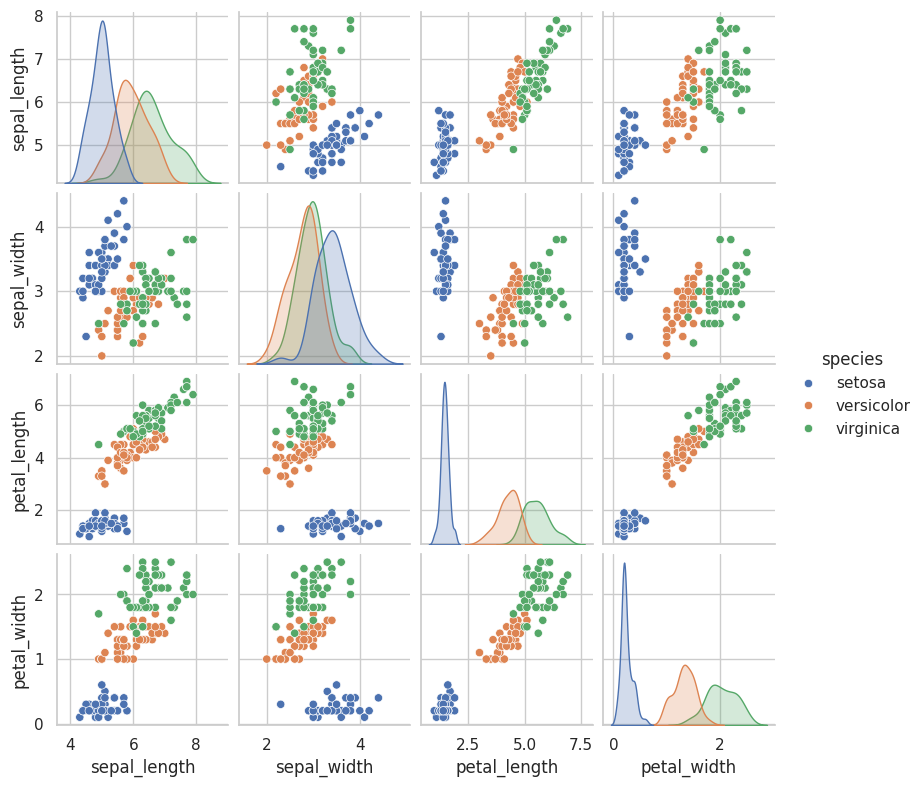

The diagonal shows each column on its own.
The other boxes show every pair of columns.
The setosa points (one colour) are clearly separated from the other two.


In [ ]:
# One command for the whole dataset
sns.pairplot(iris, hue="species", height=2.0)
plt.show()

print("The diagonal shows each column on its own.")
print("The other boxes show every pair of columns.")
print("The setosa points (one colour) are clearly separated from the other two.")

---
## 10. Styles and colour palettes

* `sns.set_style()` changes the background. The five choices are
  `"white"`, `"dark"`, `"whitegrid"`, `"darkgrid"` and `"ticks"`.
* `palette=` changes the set of colours. Common ones: `"deep"`, `"Set2"`,
  `"pastel"`, `"Blues"`, `"viridis"`.

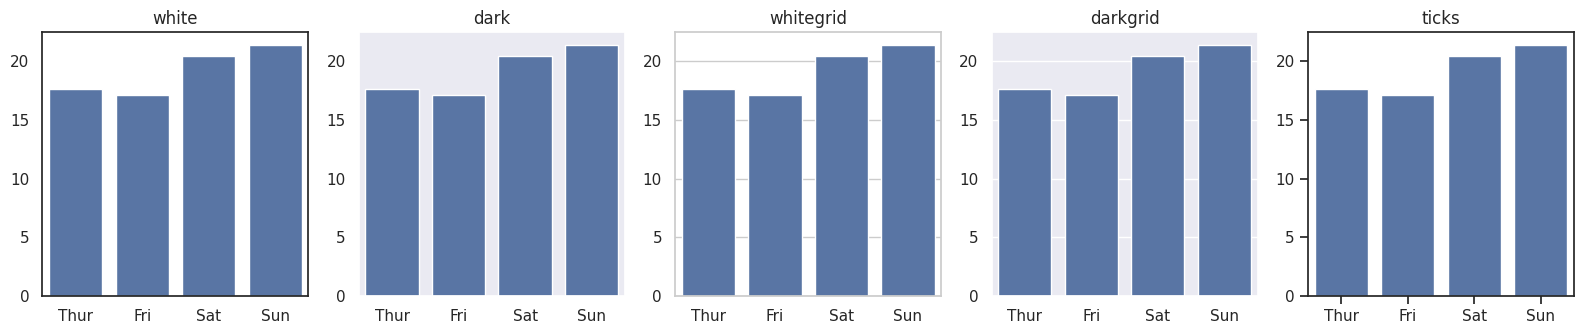

In [ ]:
# The five styles
fig = plt.figure(figsize=(16, 3.5))

for i, style in enumerate(["white", "dark", "whitegrid", "darkgrid", "ticks"], start=1):
    with sns.axes_style(style):           # use this style for one plot only
        ax = fig.add_subplot(1, 5, i)
        sns.barplot(data=tips, x="day", y="total_bill", errorbar=None, ax=ax)
        ax.set_title(style)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

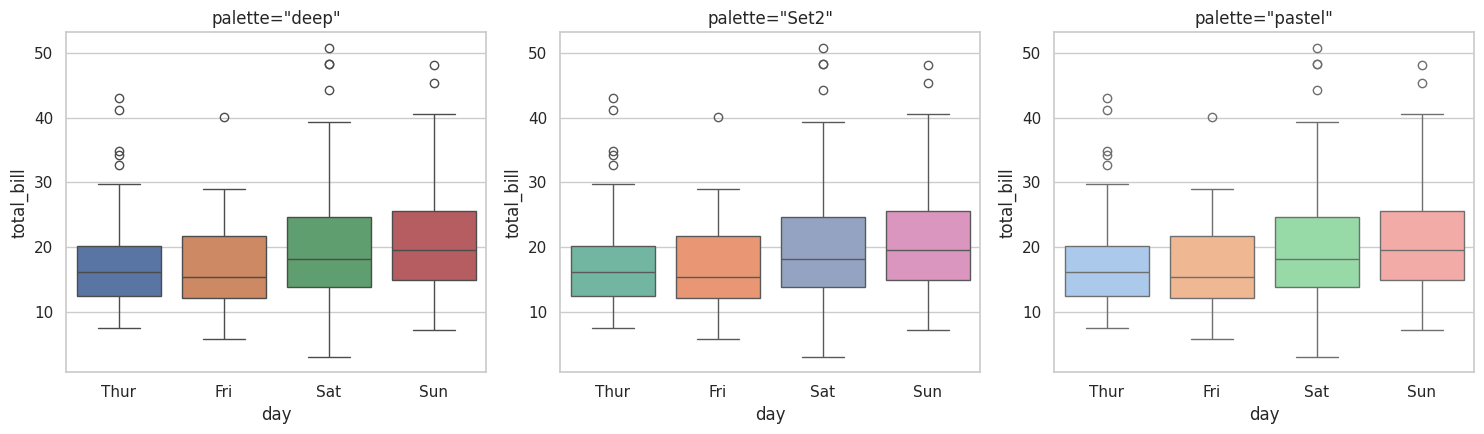

Tip: when you use palette= with a category, also pass hue= for that column.


In [ ]:
# Three colour palettes
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name in zip(axes, ["deep", "Set2", "pastel"]):
    sns.boxplot(data=tips, x="day", y="total_bill", hue="day",
                palette=name, legend=False, ax=ax)
    ax.set_title('palette="' + name + '"')

plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")     # go back to the style used in this lab
print("Tip: when you use palette= with a category, also pass hue= for that column.")

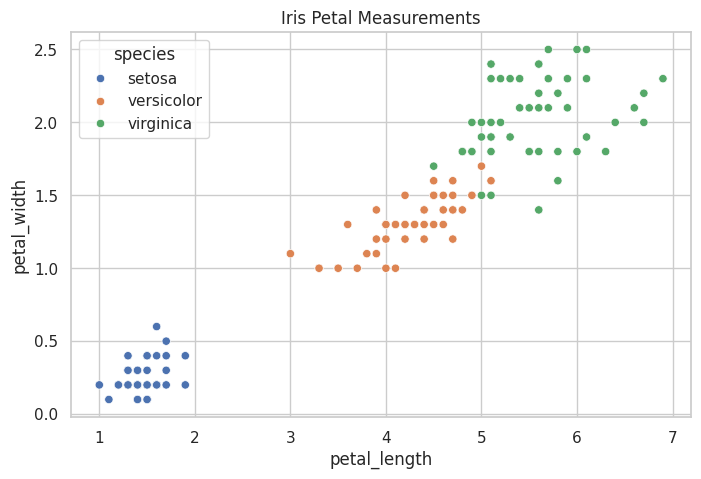

File created: True


In [ ]:
# Saving a Seaborn plot: it is a normal Matplotlib figure, so savefig works
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species", ax=ax)
ax.set_title("Iris Petal Measurements")

fig.savefig("seaborn_plot.png", dpi=300, bbox_inches="tight")
plt.show()

import os
print("File created:", os.path.exists("seaborn_plot.png"))